# Customer Churn Prediction Using Machine Learning

Customer churn prediction helps a business identify customers who are likely to stop using a service. If churn can be predicted early, the company can offer retention actions such as improved support, personalized discounts, or plan changes before the customer leaves.

**Project objective:** build and evaluate supervised machine learning models that predict whether a customer will churn.

This is a **binary classification** problem because the target variable, `Churn`, has two possible classes:

- `0`: customer did not churn
- `1`: customer churned


## 2. Problem Definition

The input variables are customer demographic, subscription, usage, spending, and interaction features such as `Age`, `Gender`, `Tenure`, `Usage Frequency`, `Support Calls`, `Payment Delay`, `Subscription Type`, `Contract Length`, `Total Spend`, and `Last Interaction`.

The output variable is `Churn`, a binary target indicating whether the customer churned.

In practical business terms, churn prediction supports targeted retention. Instead of offering incentives to every customer, a company can focus attention on customers who are most at risk.

Classification errors have different meanings:

- **False positive:** the model predicts that a customer will churn, but the customer actually stays. This may lead to unnecessary retention cost.
- **False negative:** the model predicts that a customer will stay, but the customer actually churns. This is especially important because the business fails to identify and intervene with a customer who was likely to leave.

For that reason, this project emphasizes **Recall**, **F1-score**, and **ROC-AUC**, not accuracy alone.


## 3. Imports and Reproducibility


In [27]:
import json
import os
import random
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


## 4. Load the Dataset

Both CSV files are loaded below. The training file is used for model development and cross-validation. The testing file is reserved for final held-out evaluation only.


In [28]:
DATA_DIR = Path("dataset")
TRAIN_PATH = DATA_DIR / "customer_churn_dataset-training-master.csv"
TEST_PATH = DATA_DIR / "customer_churn_dataset-testing-master.csv"

if not TRAIN_PATH.exists():
    TRAIN_PATH = Path("customer_churn_dataset-training-master.csv")
if not TEST_PATH.exists():
    TEST_PATH = Path("customer_churn_dataset-testing-master.csv")

train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)

print("Training shape:", train_raw.shape)
print("Testing shape:", test_raw.shape)
display(train_raw.head())
display(test_raw.head())

print("Training columns:")
print(train_raw.columns.tolist())

print("\nTraining data types:")
display(train_raw.dtypes.to_frame("dtype"))


Training shape: (440833, 12)
Testing shape: (64374, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


Training columns:
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']

Training data types:


,dtype
CustomerID,float64
Age,float64
Gender,str
Tenure,float64
Usage Frequency,float64
Support Calls,float64
Payment Delay,float64
Subscription Type,str
Contract Length,str
Total Spend,float64


## 5. Data Understanding and Initial Inspection


In [29]:
def inspect_dataframe(df, name):
    print(f"===== {name} =====")
    print("Shape:", df.shape)
    print("\nMissing values:")
    display(df.isna().sum().to_frame("missing_count"))
    print("\nDuplicate rows:", df.duplicated().sum())
    print("\nTarget distribution:")
    display(df["Churn"].value_counts(dropna=False).to_frame("count"))
    print("\nTarget distribution (%):")
    display((df["Churn"].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percent"))

inspect_dataframe(train_raw, "Training Data")
inspect_dataframe(test_raw, "Testing Data")


===== Training Data =====
Shape: (440833, 12)

Missing values:


,missing_count
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1



Duplicate rows: 0

Target distribution:


,count
Churn,
1.0,249999
0.0,190833
NaN,1



Target distribution (%):


...

,missing_count
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0



Duplicate rows: 0

Target distribution:


,count
Churn,
0,33881
1,30493



Target distribution (%):


,percent
Churn,
0,52.63
1,47.37


In [30]:
numeric_cols_raw = train_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_raw = train_raw.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical features/columns:", numeric_cols_raw)
print("Categorical features/columns:", categorical_cols_raw)

print("\nDescriptive statistics for numerical columns:")
display(train_raw[numeric_cols_raw].describe().T)

print("\nFrequency tables for categorical columns:")
for col in categorical_cols_raw:
    print(f"\n{col}")
    display(train_raw[col].value_counts(dropna=False).to_frame("count"))


Numerical features/columns: ['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn']
Categorical features/columns: ['Gender', 'Subscription Type', 'Contract Length']

Descriptive statistics for numerical columns:


,count,mean,std,min,25%,50%,75%,max
CustomerID,440832.0,225398.667955,129531.918550,2.0,113621.75,226125.5,337739.25,449999.0
Age,440832.0,39.373153,12.442369,18.0,29.00,39.0,48.00,65.0
Tenure,440832.0,31.256336,17.255727,1.0,16.00,32.0,46.00,60.0
Usage Frequency,440832.0,15.807494,8.586242,1.0,9.00,16.0,23.00,30.0
Support Calls,440832.0,3.604437,3.070218,0.0,1.00,3.0,6.00,10.0
Payment Delay,440832.0,12.965722,8.258063,0.0,6.00,12.0,19.00,30.0
Total Spend,440832.0,631.616223,240.803001,100.0,480.00,661.0,830.00,1000.0
Last Interaction,440832.0,14.480868,8.596208,1.0,7.00,14.0,22.00,30.0
Churn,440832.0,0.567107,0.495477,0.0,0.00,1.0,1.00,1.0



Frequency tables for categorical columns:

Gender


,count
Gender,
Male,250252
Female,190580
NaN,1



Subscription Type


,count
Subscription Type,
Standard,149128
Premium,148678
Basic,143026
NaN,1



Contract Length


,count
Contract Length,
Annual,177198
Quarterly,176530
Monthly,87104
NaN,1


**Initial inspection interpretation:** the training set contains one malformed almost-empty row with missing values, including a missing `Churn` target. That row cannot be used for supervised learning and must be removed. The class distribution is not perfectly balanced; churned customers are the larger class in the training data, so the dataset is **moderately imbalanced** rather than extremely imbalanced.


## 6. Data Cleaning


In [31]:
train_clean = train_raw.copy()
test_clean = test_raw.copy()

rows_before = len(train_clean)
train_clean = train_clean.dropna(how="all")
train_clean = train_clean.dropna(subset=["Churn"])
rows_after = len(train_clean)

print(f"Removed {rows_before - rows_after} malformed/missing-target training row(s).")
print("Remaining missing target values in training:", train_clean["Churn"].isna().sum())
print("Remaining missing target values in testing:", test_clean["Churn"].isna().sum())

train_clean["Churn"] = train_clean["Churn"].astype(int)
test_clean["Churn"] = test_clean["Churn"].astype(int)

feature_columns = [col for col in train_clean.columns if col not in ["CustomerID", "Churn"]]
target_column = "Churn"

X_train_full = train_clean[feature_columns].copy()
y_train_full = train_clean[target_column].copy()
X_test = test_clean[feature_columns].copy()
y_test = test_clean[target_column].copy()

print("Feature columns used for modelling:")
print(feature_columns)
print("\nExcluded columns: CustomerID, Churn")
print("Target dtype:", y_train_full.dtype)
display(y_train_full.value_counts().to_frame("count"))


Removed 1 malformed/missing-target training row(s).
Remaining missing target values in training: 0
Remaining missing target values in testing: 0
Feature columns used for modelling:
['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']

Excluded columns: CustomerID, Churn
Target dtype: int64


,count
Churn,
1,249999
0,190833


**Cleaning interpretation:** `CustomerID` is excluded because it is an identifier, not a meaningful predictive feature. Keeping it could cause the model to learn arbitrary ID patterns rather than general customer behavior.


## 7. Exploratory Data Analysis


In [32]:
eda_df = train_clean.sample(n=min(50000, len(train_clean)), random_state=RANDOM_STATE)
numeric_features = X_train_full.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train_full.select_dtypes(exclude=[np.number]).columns.tolist()

print("EDA sample shape:", eda_df.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


EDA sample shape: (50000, 12)
Numeric features: ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']
Categorical features: ['Gender', 'Subscription Type', 'Contract Length']


### Churn Class Distribution


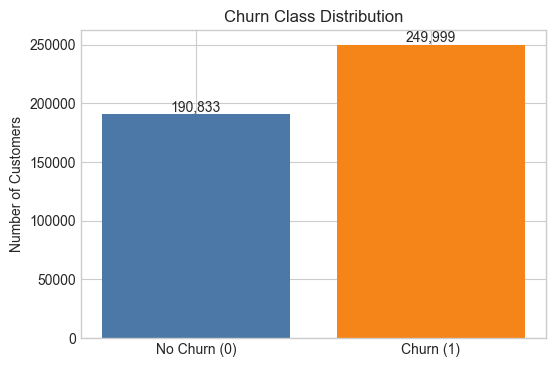

In [33]:
class_counts = train_clean["Churn"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["No Churn (0)", "Churn (1)"], class_counts.values, color=["#4C78A8", "#F58518"])
ax.set_title("Churn Class Distribution")
ax.set_ylabel("Number of Customers")
for i, value in enumerate(class_counts.values):
    ax.text(i, value, f"{value:,}", ha="center", va="bottom")
plt.show()


**Interpretation:** both classes are well represented, but the training data contains more churned than non-churned customers. This supports using stratified cross-validation and metrics beyond accuracy.


### Numerical Feature Distributions


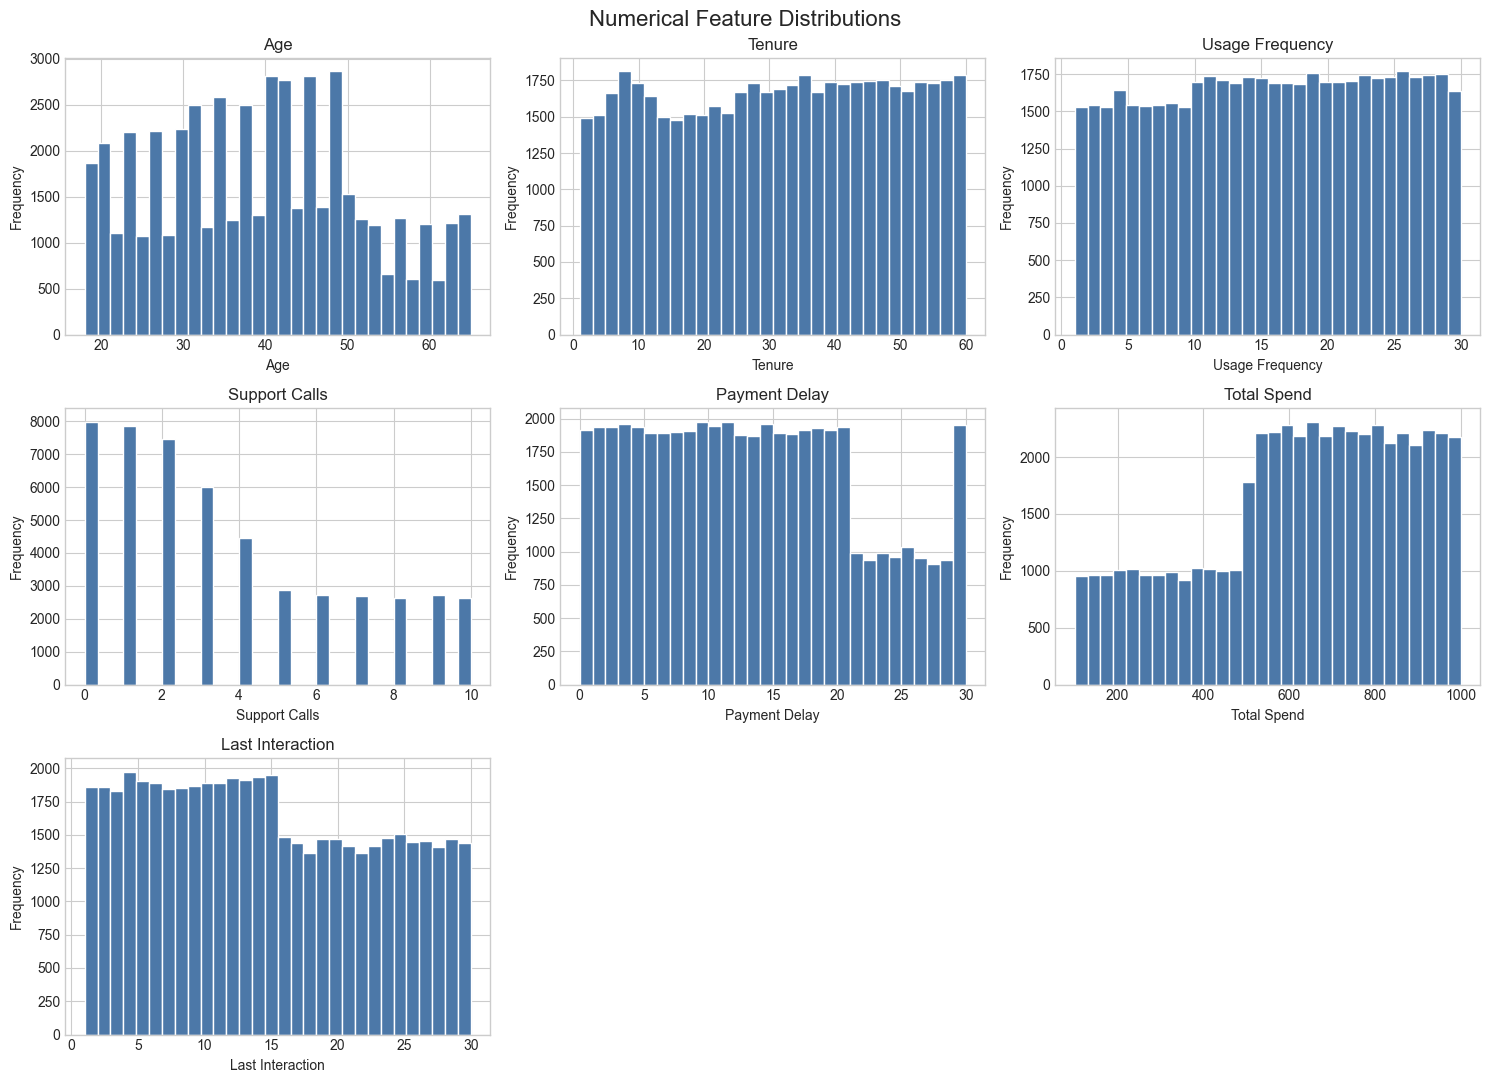

In [34]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 11))
axes = axes.ravel()

for idx, col in enumerate(numeric_features):
    axes[idx].hist(eda_df[col].dropna(), bins=30, color="#4C78A8", edgecolor="white")
    axes[idx].set_title(col)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Frequency")

for j in range(len(numeric_features), len(axes)):
    axes[j].axis("off")

fig.suptitle("Numerical Feature Distributions", fontsize=16)
fig.tight_layout()
plt.show()


**Interpretation:** the numerical variables have different ranges, for example `Total Spend` is on a much larger scale than `Support Calls`. This supports using scaling for distance-based and linear models.


### Churn Rate by Categorical Features


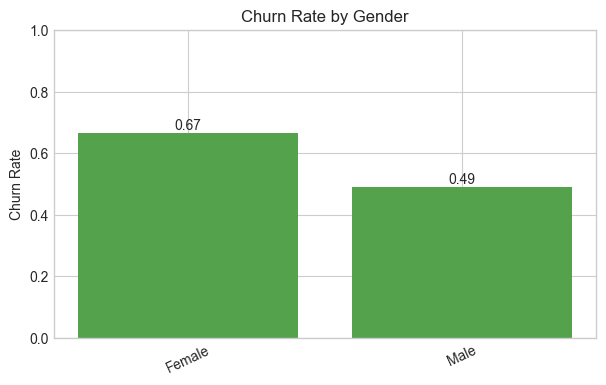

,churn_rate
Gender,
Female,0.667
Male,0.491


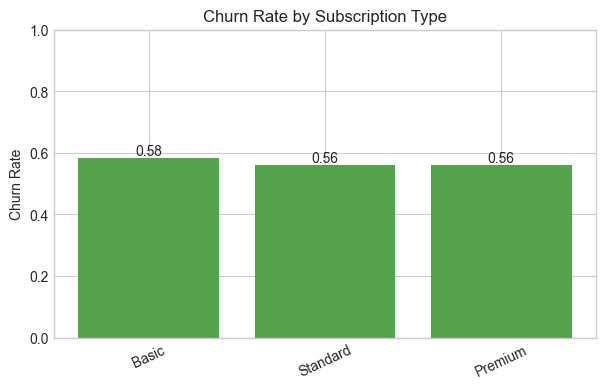

,churn_rate
Subscription Type,
Basic,0.582
Standard,0.561
Premium,0.559


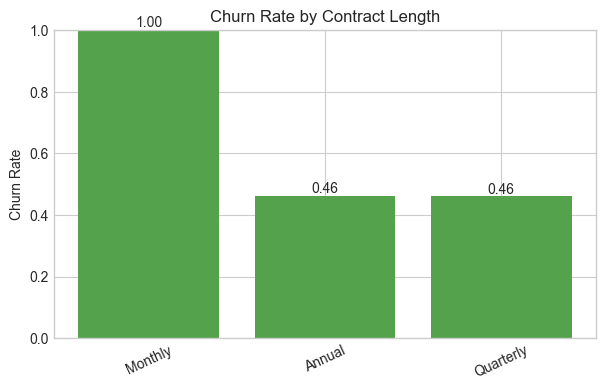

,churn_rate
Contract Length,
Monthly,1.000
Annual,0.461
Quarterly,0.460


In [35]:
def plot_churn_rate_by_category(df, column):
    churn_rate = df.groupby(column)["Churn"].mean().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(churn_rate.index.astype(str), churn_rate.values, color="#54A24B")
    ax.set_title(f"Churn Rate by {column}")
    ax.set_ylabel("Churn Rate")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=25)
    for i, value in enumerate(churn_rate.values):
        ax.text(i, value, f"{value:.2f}", ha="center", va="bottom")
    plt.show()
    display(churn_rate.to_frame("churn_rate").round(3))

for col in ["Gender", "Subscription Type", "Contract Length"]:
    plot_churn_rate_by_category(train_clean, col)


**Interpretation:** these grouped churn rates show whether churn differs across customer segments. The model can use these associations, but they should not be interpreted as causal effects without further business or experimental evidence.


### Numerical Variables Compared With Churn


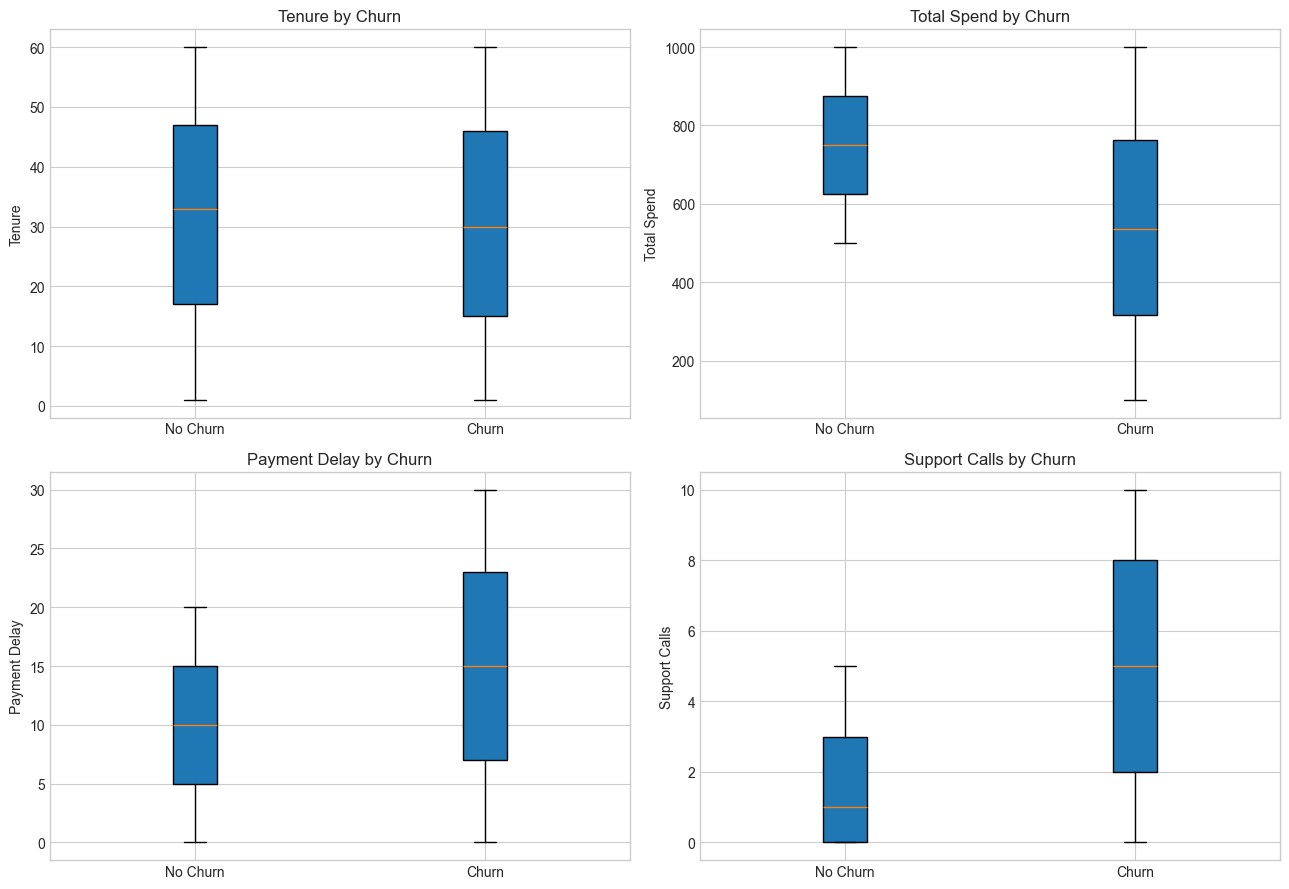

In [36]:
boxplot_features = ["Tenure", "Total Spend", "Payment Delay", "Support Calls"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

for ax, col in zip(axes, boxplot_features):
    data_0 = eda_df.loc[eda_df["Churn"] == 0, col].dropna()
    data_1 = eda_df.loc[eda_df["Churn"] == 1, col].dropna()
    ax.boxplot([data_0, data_1], labels=["No Churn", "Churn"], patch_artist=True)
    ax.set_title(f"{col} by Churn")
    ax.set_ylabel(col)

fig.tight_layout()
plt.show()


**Interpretation:** boxplots help compare the distribution of important customer behavior variables between churned and retained customers. Visible shifts between the two boxes suggest useful predictive signal for classification.


### Correlation Heatmap for Numeric Features


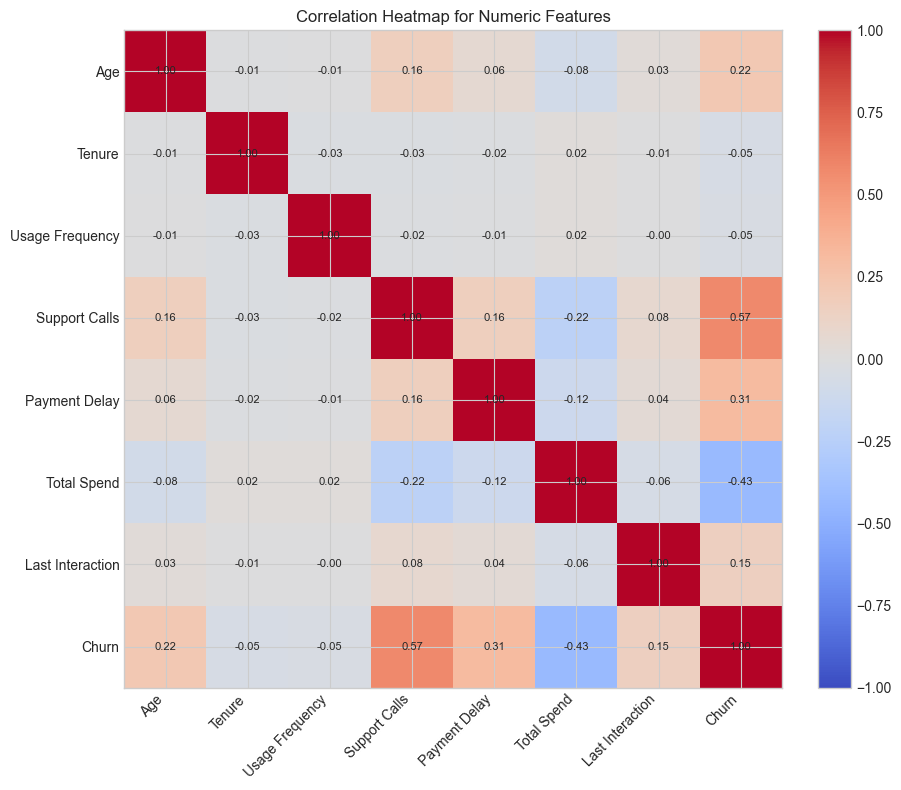

In [37]:
corr_cols = numeric_features + ["Churn"]
corr = train_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
ax.set_title("Correlation Heatmap for Numeric Features")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()


**Interpretation:** correlations summarize linear relationships among numeric variables. Strong correlations with `Churn` may be predictive, while strong correlations among input features may indicate overlapping information.


## 8. Train/Test Strategy


The provided training dataset is used for model training, cross-validation, and hyperparameter tuning. The provided testing dataset is used only once for final held-out evaluation after model selection.

This separation is important because using the external testing set during training or tuning would leak information about the final evaluation data. Leakage would make the reported performance overly optimistic and scientifically unfair.

The training dataset has more than 440,000 rows. To keep the notebook practical for a classroom or laptop environment, cross-validation and tuning below use a **stratified development sample** drawn only from the training file. This preserves class proportions while keeping KNN and repeated model fitting computationally reasonable. The external test set remains untouched until the final evaluation section.


In [38]:
CV_SAMPLE_SIZE = 30000

if len(X_train_full) > CV_SAMPLE_SIZE:
    X_dev, _, y_dev, _ = train_test_split(
        X_train_full,
        y_train_full,
        train_size=CV_SAMPLE_SIZE,
        stratify=y_train_full,
        random_state=RANDOM_STATE,
    )
else:
    X_dev = X_train_full.copy()
    y_dev = y_train_full.copy()

print("Full training shape:", X_train_full.shape)
print("Development/CV training shape:", X_dev.shape)
print("Held-out external test shape:", X_test.shape)
print("\nDevelopment target distribution:")
display(y_dev.value_counts(normalize=True).rename("proportion").to_frame())


Full training shape: (440832, 10)
Development/CV training shape: (30000, 10)
Held-out external test shape: (64374, 10)

Development target distribution:


,proportion
Churn,
1,0.5671
0,0.4329


## 9. Preprocessing Pipeline


In [39]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("Numeric preprocessing: median imputation + StandardScaler")
print("Categorical preprocessing: most-frequent imputation + OneHotEncoder(handle_unknown='ignore')")


Numeric preprocessing: median imputation + StandardScaler
Categorical preprocessing: most-frequent imputation + OneHotEncoder(handle_unknown='ignore')


The preprocessing is inside a `ColumnTransformer` and later inside each model `Pipeline`. This ensures imputers, scalers, and encoders are fitted only on each training fold during cross-validation, avoiding data leakage.


## 10. Models to Compare


This project compares exactly three distinct supervised machine learning models:

**A. Logistic Regression**

Logistic Regression is a linear probabilistic classifier. It estimates the probability of churn using a weighted combination of the input features. It is included as an interpretable baseline. Important hyperparameters include `C`, `penalty`, `solver`, and `class_weight`. Its strengths are speed and interpretability; its weakness is that it may underfit nonlinear relationships.

**B. K-Nearest Neighbors**

KNN is a distance-based non-parametric method. It predicts a customer's class based on nearby customers in feature space. It is included because it uses a very different learning principle from Logistic Regression and Random Forest. Important hyperparameters include `n_neighbors`, `weights`, and `metric`. Its strength is flexibility; its weaknesses are prediction cost and sensitivity to scaling, which is why scaling is required.

**C. Random Forest Classifier**

Random Forest is an ensemble of decision trees. It can capture nonlinear patterns and interactions between features. Important hyperparameters include `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, and `class_weight`. Its strengths are strong predictive performance and feature importance estimates; its weaknesses are reduced interpretability compared with Logistic Regression and higher computational cost.


In [40]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
}

pipelines = {
    name: Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )
    for name, model in models.items()
}

pipelines


{'Logistic Regression': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['Age', 'Tenure',
                                                    'Usage Frequency',
                                                    'Support Calls',
                                                    'Payment Delay',
                                                    'Total Spend',
                                                    'Last Interaction']),
                                                  ('cat',
                                                   Pipeline

## 11. Baseline Model Training


In [41]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

def evaluate_models_cv(model_dict, X, y, cv, scoring):
    rows = []
    for name, model in model_dict.items():
        print(f"Cross-validating {name}...")
        scores = cross_validate(
            model,
            X,
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=False,
        )
        row = {"Model": name}
        for metric in scoring:
            values = scores[f"test_{metric}"]
            row[f"{metric}_mean"] = values.mean()
            row[f"{metric}_std"] = values.std()
        rows.append(row)
    return pd.DataFrame(rows).sort_values("f1_mean", ascending=False)

baseline_cv_results = evaluate_models_cv(pipelines, X_dev, y_dev, cv, scoring)
display(baseline_cv_results.round(4))


Cross-validating Logistic Regression...
Cross-validating K-Nearest Neighbors...
Cross-validating Random Forest...


,Model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
2,Random Forest,0.9920,0.0004,0.9983,0.0007,0.9875,0.0002,0.9929,0.0003,0.9998,0.0001
1,K-Nearest Neighbors,0.9318,0.0011,0.9965,0.0019,0.8829,0.0004,0.9362,0.0010,0.9776,0.0010
0,Logistic Regression,0.8981,0.0029,0.9275,0.0051,0.8899,0.0006,0.9083,0.0024,0.9613,0.0023


**Baseline interpretation:** the baseline comparison establishes how the three model families perform before tuning. Because churn detection has business risk, the most important columns are `recall_mean`, `f1_mean`, and `roc_auc_mean`.


## 12. Hyperparameter Tuning


The primary optimization metric is **F1-score**. F1 is appropriate because it balances precision and recall for the churn class. Recall matters because false negatives mean failing to identify customers likely to churn, but precision also matters because retention campaigns have costs.

`StratifiedKFold` is used so that each fold keeps approximately the same churn/non-churn class proportions. Randomized search is used for KNN and Random Forest to keep the notebook computationally reasonable.


In [42]:
param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__penalty": ["l2"],
        "model__solver": ["liblinear", "lbfgs"],
        "model__class_weight": [None, "balanced"],
    },
    "K-Nearest Neighbors": {
        "model__n_neighbors": [3, 5, 7, 11, 15],
        "model__weights": ["uniform", "distance"],
        "model__metric": ["euclidean", "manhattan"],
    },
    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__class_weight": [None, "balanced"],
    },
}

tuned_searches = {}
best_estimators = {}
tuning_rows = []

for name, pipeline in pipelines.items():
    print(f"Tuning {name}...")
    if name == "Logistic Regression":
        search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[name],
            scoring="f1",
            cv=cv,
            n_jobs=-1,
            refit=True,
        )
    elif name == "K-Nearest Neighbors":
        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_grids[name],
            n_iter=10,
            scoring="f1",
            cv=cv,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            refit=True,
        )
    else:
        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_grids[name],
            n_iter=12,
            scoring="f1",
            cv=cv,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            refit=True,
        )

    search.fit(X_dev, y_dev)
    tuned_searches[name] = search
    best_estimators[name] = search.best_estimator_
    tuning_rows.append(
        {
            "Model": name,
            "Best CV F1": search.best_score_,
            "Best Parameters": search.best_params_,
        }
    )

tuning_summary = pd.DataFrame(tuning_rows).sort_values("Best CV F1", ascending=False)
display(tuning_summary)


Tuning Logistic Regression...
Tuning K-Nearest Neighbors...
Tuning Random Forest...


,Model,Best CV F1,Best Parameters
2,Random Forest,0.992850,"{'model__n_estimators': 200, 'model__min_sampl..."
1,K-Nearest Neighbors,0.939924,"{'model__weights': 'distance', 'model__n_neigh..."
0,Logistic Regression,0.909096,"{'model__C': 1, 'model__class_weight': 'balanc..."


## 13. Best Model Comparison After Tuning


Cross-validating Logistic Regression...
Cross-validating K-Nearest Neighbors...
Cross-validating Random Forest...


,Model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
2,Random Forest,0.9919,0.0001,0.9981,0.0005,0.9877,0.0004,0.9929,0.0001,0.9999,0.0000
1,K-Nearest Neighbors,0.9353,0.0007,0.9921,0.0013,0.8930,0.0021,0.9399,0.0007,0.9717,0.0014
0,Logistic Regression,0.9005,0.0027,0.9437,0.0047,0.8770,0.0012,0.9091,0.0022,0.9613,0.0023


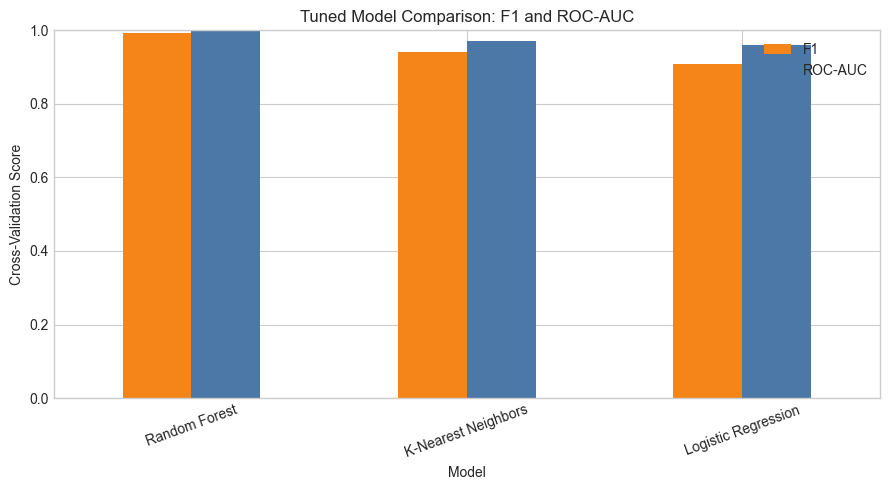

In [43]:
tuned_cv_results = evaluate_models_cv(best_estimators, X_dev, y_dev, cv, scoring)
display(tuned_cv_results.round(4))

plot_df = tuned_cv_results.set_index("Model")[["f1_mean", "roc_auc_mean"]]
ax = plot_df.plot(kind="bar", figsize=(9, 5), color=["#F58518", "#4C78A8"])
ax.set_title("Tuned Model Comparison: F1 and ROC-AUC")
ax.set_ylabel("Cross-Validation Score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=20)
plt.legend(["F1", "ROC-AUC"])
plt.tight_layout()
plt.show()


**Tuned model interpretation:** the best model should be judged by a combination of F1, recall, and ROC-AUC. A model with slightly lower accuracy may still be preferable if it identifies churners more reliably.


## 14. Final Evaluation on the Held-Out Testing Set


In [44]:
def get_positive_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return (scores - scores.min()) / (scores.max() - scores.min())
    return model.predict(X)

def evaluate_on_test(model_dict, X_test, y_test):
    rows = []
    predictions = {}
    probabilities = {}

    for name, model in model_dict.items():
        y_pred = model.predict(X_test)
        y_score = get_positive_scores(model, X_test)
        predictions[name] = y_pred
        probabilities[name] = y_score

        rows.append(
            {
                "Model": name,
                "Accuracy": accuracy_score(y_test, y_pred),
                "Precision": precision_score(y_test, y_pred, zero_division=0),
                "Recall": recall_score(y_test, y_pred, zero_division=0),
                "F1": f1_score(y_test, y_pred, zero_division=0),
                "ROC-AUC": roc_auc_score(y_test, y_score),
            }
        )

    return pd.DataFrame(rows).sort_values("F1", ascending=False), predictions, probabilities

final_test_results, test_predictions, test_probabilities = evaluate_on_test(best_estimators, X_test, y_test)
display(final_test_results.round(4))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.5807,0.5309,0.9876,0.6905,0.7032
1,K-Nearest Neighbors,0.5549,0.5160,0.9745,0.6747,0.6021
2,Random Forest,0.5105,0.4918,0.9984,0.6589,0.6720


In [45]:
for name in final_test_results["Model"]:
    print("=" * 80)
    print(name)
    print(classification_report(y_test, test_predictions[name], target_names=["No Churn", "Churn"]))


Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.95      0.21      0.35     33881
       Churn       0.53      0.99      0.69     30493

    accuracy                           0.58     64374
   macro avg       0.74      0.60      0.52     64374
weighted avg       0.75      0.58      0.51     64374

K-Nearest Neighbors
              precision    recall  f1-score   support

    No Churn       0.89      0.18      0.30     33881
       Churn       0.52      0.97      0.67     30493

    accuracy                           0.55     64374
   macro avg       0.70      0.58      0.49     64374
weighted avg       0.71      0.55      0.48     64374

Random Forest
              precision    recall  f1-score   support

    No Churn       0.98      0.07      0.13     33881
       Churn       0.49      1.00      0.66     30493

    accuracy                           0.51     64374
   macro avg       0.74      0.53      0.40     64374
weighted avg       0

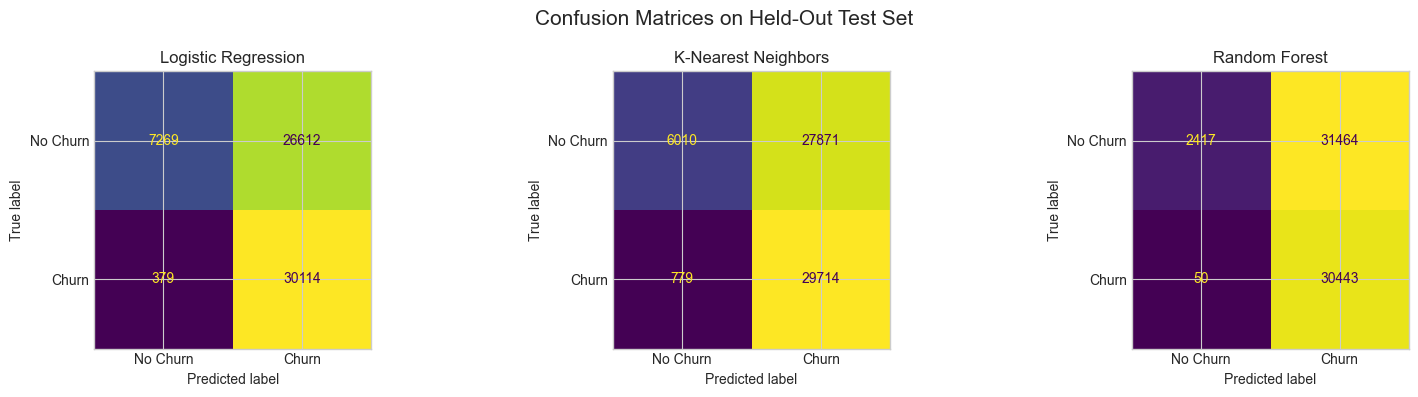

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, name in zip(axes, final_test_results["Model"]):
    cm = confusion_matrix(y_test, test_predictions[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(name)

fig.suptitle("Confusion Matrices on Held-Out Test Set", fontsize=15)
fig.tight_layout()
plt.show()


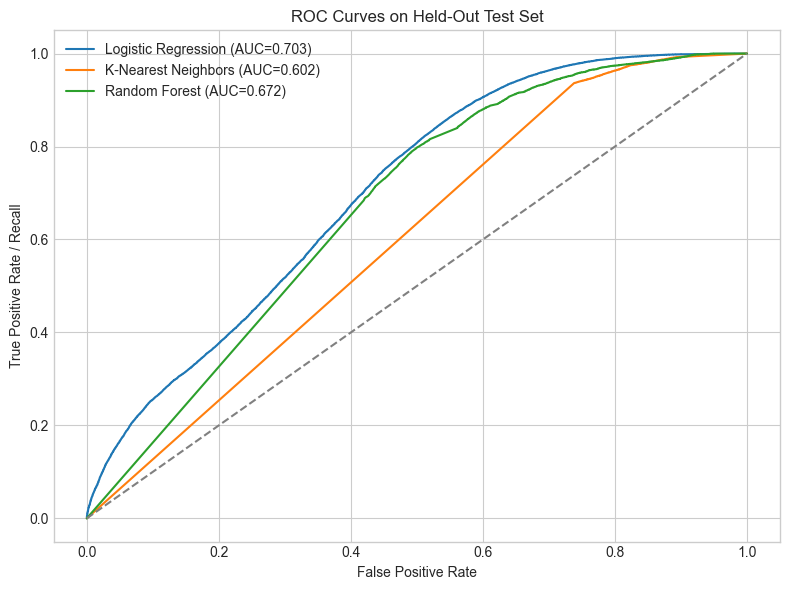

In [47]:
fig, ax = plt.subplots(figsize=(8, 6))

for name in final_test_results["Model"]:
    fpr, tpr, _ = roc_curve(y_test, test_probabilities[name])
    auc_value = roc_auc_score(y_test, test_probabilities[name])
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_value:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("ROC Curves on Held-Out Test Set")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate / Recall")
ax.legend()
plt.tight_layout()
plt.show()


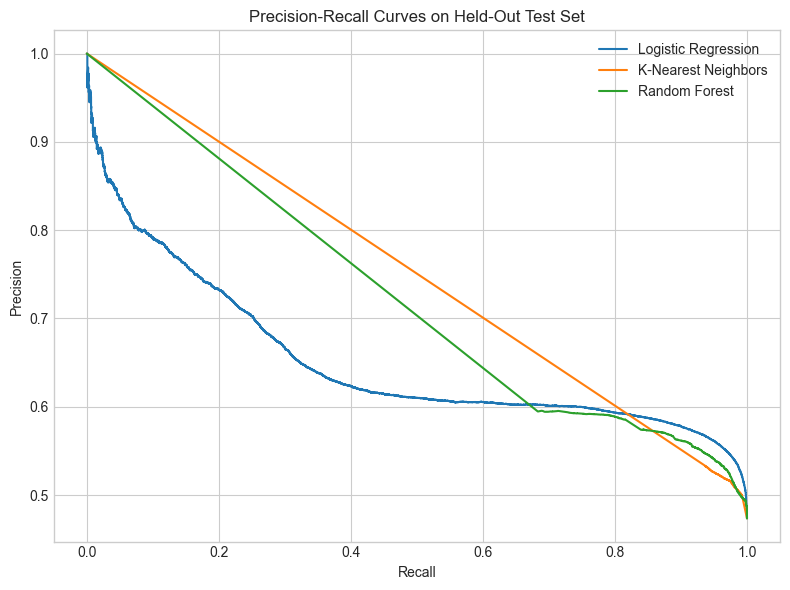

In [48]:
fig, ax = plt.subplots(figsize=(8, 6))

for name in final_test_results["Model"]:
    precision, recall, _ = precision_recall_curve(y_test, test_probabilities[name])
    ax.plot(recall, precision, label=name)

ax.set_title("Precision-Recall Curves on Held-Out Test Set")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
plt.tight_layout()
plt.show()


**Final evaluation interpretation:** these metrics are computed only on the external test dataset. This table and the diagnostic plots provide the fairest estimate of how the tuned models generalize to unseen customer records from the provided test file.


## 15. Scientific Interpretation


In [49]:
comparison = final_test_results.merge(
    tuned_cv_results[["Model", "f1_mean", "roc_auc_mean", "recall_mean"]],
    on="Model",
    how="left",
).rename(
    columns={
        "f1_mean": "CV F1",
        "roc_auc_mean": "CV ROC-AUC",
        "recall_mean": "CV Recall",
    }
)

display(comparison.round(4))

selected_model_name = final_test_results.sort_values(
    by=["F1", "Recall", "ROC-AUC"],
    ascending=False,
).iloc[0]["Model"]
selected_model = best_estimators[selected_model_name]

print("Selected final model:", selected_model_name)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,CV F1,CV ROC-AUC,CV Recall
0,Logistic Regression,0.5807,0.5309,0.9876,0.6905,0.7032,0.9091,0.9613,0.8770
1,K-Nearest Neighbors,0.5549,0.5160,0.9745,0.6747,0.6021,0.9399,0.9717,0.8930
2,Random Forest,0.5105,0.4918,0.9984,0.6589,0.6720,0.9929,0.9999,0.9877


Selected final model: Logistic Regression


## 15B. Save Model and Dashboard Artifacts

The dashboard uses the saved final model pipeline and evaluation artifacts created below. The saved model is the complete scikit-learn pipeline, including preprocessing and classifier, so it can accept raw customer feature rows directly.


In [50]:
ARTIFACT_MODEL_PATH = "churn_prediction_model.pkl"
ARTIFACT_METRICS_PATH = "model_metrics.json"
ARTIFACT_COMPARISON_PATH = "model_comparison.csv"

# Refit the selected pipeline on the full cleaned training dataset before saving.
# This keeps preprocessing and the final classifier bundled together for deployment.
final_model_pipeline = selected_model
final_model_pipeline.fit(X_train_full, y_train_full)
selected_model = final_model_pipeline

model_comparison_export = final_test_results.copy()
model_comparison_export.to_csv(ARTIFACT_COMPARISON_PATH, index=False)

selected_metrics = (
    model_comparison_export.loc[model_comparison_export["Model"] == selected_model_name]
    .iloc[0]
    .drop(labels=["Model"])
    .to_dict()
)

metrics_payload = {
    "selected_model": selected_model_name,
    "selection_reason": (
        "Selected using held-out test performance with emphasis on F1, Recall, and ROC-AUC "
        "because churn detection should reduce missed churn-risk customers."
    ),
    "positive_class": "Churn = 1",
    "metrics": model_comparison_export.to_dict(orient="records"),
    "selected_model_metrics": {key: float(value) for key, value in selected_metrics.items()},
    "feature_columns": feature_columns,
}

with open(ARTIFACT_METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2)

joblib.dump(final_model_pipeline, ARTIFACT_MODEL_PATH)

print(f"Saved final model pipeline to: {ARTIFACT_MODEL_PATH}")
print(f"Saved model metrics to: {ARTIFACT_METRICS_PATH}")
print(f"Saved model comparison table to: {ARTIFACT_COMPARISON_PATH}")


Saved final model pipeline to: churn_prediction_model.pkl
Saved model metrics to: model_metrics.json
Saved model comparison table to: model_comparison.csv


**Scientific interpretation:** compare cross-validation performance with final test performance. If test performance is much lower than cross-validation performance, that may indicate overfitting or distribution differences between the training and testing files. The selected model should be justified by business-relevant metrics, especially F1 and recall for the churn class, rather than accuracy alone.


## 16. Feature Importance / Interpretability


Top positive Logistic Regression coefficients associated with higher predicted churn:


,feature,coefficient
13,cat__Contract Length_Monthly,7.635745
3,num__Support Calls,2.340938
7,cat__Gender_Female,1.494851
4,num__Payment Delay,0.933599
9,cat__Subscription Type_Basic,0.689516
11,cat__Subscription Type_Standard,0.569811
10,cat__Subscription Type_Premium,0.567108
6,num__Last Interaction,0.530835
0,num__Age,0.426235
8,cat__Gender_Male,0.331584


Top negative Logistic Regression coefficients associated with lower predicted churn:


,feature,coefficient
14,cat__Contract Length_Quarterly,-2.907219
12,cat__Contract Length_Annual,-2.902091
5,num__Total Spend,-1.487274
1,num__Tenure,-0.132360
2,num__Usage Frequency,-0.126774
8,cat__Gender_Male,0.331584
0,num__Age,0.426235
6,num__Last Interaction,0.530835
10,cat__Subscription Type_Premium,0.567108
11,cat__Subscription Type_Standard,0.569811


Top Random Forest feature importances:


,feature,importance
3,num__Support Calls,0.292220
5,num__Total Spend,0.210336
0,num__Age,0.131969
4,num__Payment Delay,0.122507
13,cat__Contract Length_Monthly,0.112714
6,num__Last Interaction,0.040410
12,cat__Contract Length_Annual,0.020721
8,cat__Gender_Male,0.019967
7,cat__Gender_Female,0.018203
14,cat__Contract Length_Quarterly,0.017355


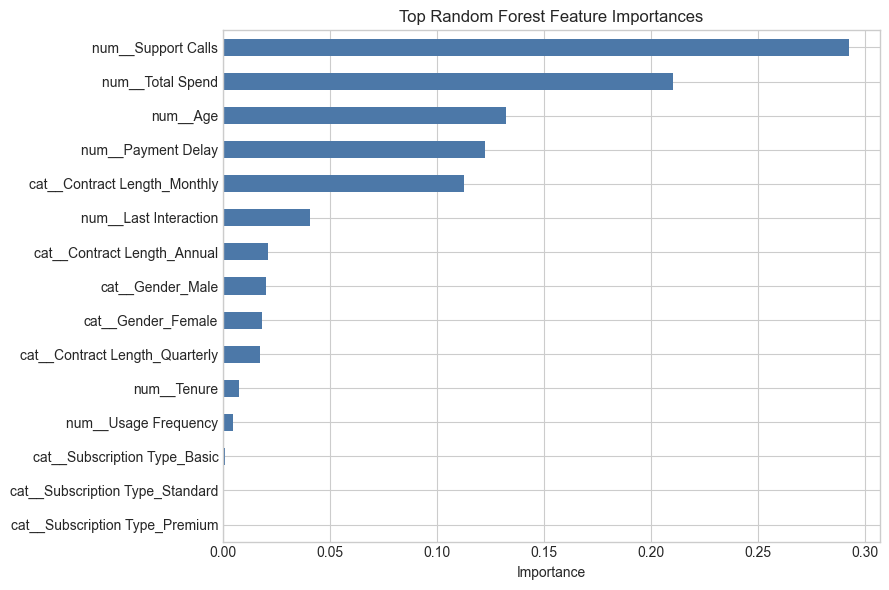

In [51]:
def get_preprocessed_feature_names(fitted_pipeline):
    pre = fitted_pipeline.named_steps["preprocessor"]
    return pre.get_feature_names_out()

if "Logistic Regression" in best_estimators:
    lr_pipeline = best_estimators["Logistic Regression"]
    lr_features = get_preprocessed_feature_names(lr_pipeline)
    lr_coef = lr_pipeline.named_steps["model"].coef_[0]
    coef_df = pd.DataFrame({"feature": lr_features, "coefficient": lr_coef})

    print("Top positive Logistic Regression coefficients associated with higher predicted churn:")
    display(coef_df.sort_values("coefficient", ascending=False).head(10))

    print("Top negative Logistic Regression coefficients associated with lower predicted churn:")
    display(coef_df.sort_values("coefficient", ascending=True).head(10))

if "Random Forest" in best_estimators:
    rf_pipeline = best_estimators["Random Forest"]
    rf_features = get_preprocessed_feature_names(rf_pipeline)
    rf_importances = rf_pipeline.named_steps["model"].feature_importances_
    rf_importance_df = pd.DataFrame({"feature": rf_features, "importance": rf_importances})
    rf_importance_df = rf_importance_df.sort_values("importance", ascending=False)

    print("Top Random Forest feature importances:")
    display(rf_importance_df.head(15))

    ax = rf_importance_df.head(15).sort_values("importance").plot(
        kind="barh",
        x="feature",
        y="importance",
        figsize=(9, 6),
        legend=False,
        color="#4C78A8",
    )
    ax.set_title("Top Random Forest Feature Importances")
    ax.set_xlabel("Importance")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


**Interpretability interpretation:** coefficients and feature importances describe associations learned by the models. For example, if support-related or payment-related variables are highly ranked, the model has learned that these variables help separate churned customers from retained customers. These are not causal claims; they are predictive patterns in the dataset.


## 17. Inference on Unseen Examples


In [52]:
new_customers = pd.DataFrame(
    [
        {
            "Age": 24,
            "Gender": "Female",
            "Tenure": 4,
            "Usage Frequency": 3,
            "Support Calls": 8,
            "Payment Delay": 25,
            "Subscription Type": "Basic",
            "Contract Length": "Monthly",
            "Total Spend": 180,
            "Last Interaction": 28,
        },
        {
            "Age": 42,
            "Gender": "Male",
            "Tenure": 48,
            "Usage Frequency": 27,
            "Support Calls": 1,
            "Payment Delay": 2,
            "Subscription Type": "Premium",
            "Contract Length": "Annual",
            "Total Spend": 980,
            "Last Interaction": 3,
        },
        {
            "Age": 61,
            "Gender": "Female",
            "Tenure": 18,
            "Usage Frequency": 12,
            "Support Calls": 4,
            "Payment Delay": 12,
            "Subscription Type": "Standard",
            "Contract Length": "Quarterly",
            "Total Spend": 520,
            "Last Interaction": 14,
        },
    ],
    columns=feature_columns,
)

new_predictions = selected_model.predict(new_customers)
new_probabilities = get_positive_scores(selected_model, new_customers)

inference_results = new_customers.copy()
inference_results["Predicted Churn Class"] = new_predictions
inference_results["Predicted Churn Probability"] = new_probabilities.round(3)

display(inference_results)


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Predicted Churn Class,Predicted Churn Probability
0,24,Female,4,3,8,25,Basic,Monthly,180,28,1,1.000
1,42,Male,48,27,1,2,Premium,Annual,980,3,0,0.002
2,61,Female,18,12,4,12,Standard,Quarterly,520,14,1,0.939


**Inference interpretation:** the first synthetic customer represents a higher-risk profile with low tenure, low usage, many support calls, and a long payment delay. The second represents a lower-risk profile with long tenure, high usage, few support calls, and an annual premium contract. The third is a mixed profile. The model predictions show how the selected final model would score new unseen customer records with the same feature structure.


## 18. Conclusion


This project built a supervised machine learning workflow for **Customer Churn Prediction**. The objective was to predict whether a customer would churn using demographic, subscription, usage, spending, and interaction features.

Three distinct models were compared: Logistic Regression, K-Nearest Neighbors, and Random Forest. Each model was placed inside a preprocessing pipeline to avoid leakage, evaluated with stratified cross-validation, tuned using F1-score, and then tested on the external held-out testing dataset.

The final model should be selected based on the held-out test comparison, especially F1-score, recall, and ROC-AUC. This is more meaningful than selecting by accuracy alone because false negatives represent missed churn-risk customers.

**Limitations:**

- The dataset may not fully represent real business churn behavior.
- Temporal effects are not explicitly modeled, even though churn often changes over time.
- The project does not include a domain-specific cost matrix for retention offers versus lost customers.
- The unseen inference examples are synthetic and used only to demonstrate prediction workflow.

**Future improvements:**

- Add cost-sensitive evaluation based on actual business retention costs.
- Test threshold tuning to increase recall when missed churners are especially costly.
- Include temporal validation if customer history dates are available.
- Add model monitoring to detect performance changes over time.
